<div style="background:linear-gradient(135deg,#0f2027 0%,#203a43 50%,#2c5364 100%);padding:32px 34px;border-radius:16px;
            box-shadow:0 8px 24px rgba(0,0,0,0.18);font-family:'Segoe UI',Roboto,sans-serif;">
  <h1 style="margin:0;color:#ffffff;font-size:34px;letter-spacing:-0.5px;">🎨&nbsp; The PINN Visualization Toolkit</h1>
  <p style="margin:12px 0 0;color:#eaf6ff;font-size:17px;line-height:1.5;max-width:760px;">A guided tour of <code>pinnlab.visualization</code> — the plotting helpers that turn raw tensors into publication-quality figures: loss curves, solution fields, vector fields, and error analysis.</p>
</div>

<div><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">level</span><span style="background:#1e9e54;color:#fff;padding:4px 8px;">beginner</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">topic</span><span style="background:#1a73e8;color:#fff;padding:4px 8px;">visualization</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">runtime</span><span style="background:#7b3fe4;color:#fff;padding:4px 8px;">~1 min · CPU</span></span></div>

Good figures are half the work in computational science. This notebook trains a quick PINN and then
showcases the `PINNVisualizer` API on real and analytic data so you can copy-paste the patterns into
your own work.

<div style="background:#f6f8fa;border:1px solid #e1e4e8;border-radius:10px;padding:18px 24px;
            font-family:'Segoe UI',sans-serif;">
  <b style="font-size:15px;">📑 Table of Contents</b>
  <ol style="margin:10px 0 0;padding-left:20px;font-size:14px;line-height:1.6;">
  <li style="margin:3px 0;"><a href="#setup" style="color:#1a73e8;text-decoration:none;">1 · Setup</a></li>
  <li style="margin:3px 0;"><a href="#train" style="color:#1a73e8;text-decoration:none;">2 · A Quick Model to Plot</a></li>
  <li style="margin:3px 0;"><a href="#loss" style="color:#1a73e8;text-decoration:none;">3 · Loss Curves</a></li>
  <li style="margin:3px 0;"><a href="#field" style="color:#1a73e8;text-decoration:none;">4 · 2-D Solution Fields</a></li>
  <li style="margin:3px 0;"><a href="#vector" style="color:#1a73e8;text-decoration:none;">5 · Vector Fields</a></li>
  <li style="margin:3px 0;"><a href="#error" style="color:#1a73e8;text-decoration:none;">6 · Error Analysis</a></li>
  <li style="margin:3px 0;"><a href="#takeaways" style="color:#1a73e8;text-decoration:none;">7 · Takeaways</a></li>
  </ol>
</div>

<a id="setup"></a>

## 1 · Setup

In [1]:
# --- Environment setup -------------------------------------------------------
import warnings, logging, os
warnings.filterwarnings("ignore")
logging.getLogger("pinnlab").setLevel(logging.ERROR)          # quiet library logs

# Disable tqdm progress bars for clean, static notebook output
from functools import partialmethod
import tqdm
tqdm.tqdm.__init__ = partialmethod(tqdm.tqdm.__init__, disable=True)

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl

# A clean, consistent "Kaggle" plotting theme ---------------------------------
plt.rcParams.update({
    "figure.figsize":   (9, 5),
    "figure.dpi":       110,
    "savefig.dpi":      110,
    "font.size":        11,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "axes.edgecolor":   "#cccccc",
    "axes.grid":        True,
    "grid.color":       "#e6e6e6",
    "grid.linewidth":   0.8,
    "axes.axisbelow":   True,
    "legend.frameon":   True,
    "legend.framealpha":0.9,
})
ACCENT, ACCENT2, ACCENT3 = "#1a73e8", "#d6336c", "#1e9e54"

# Reproducibility -------------------------------------------------------------
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

import pinnlab
print(f"pinnlab      : {pinnlab.__version__}")
print(f"PyTorch      : {torch.__version__}")
print(f"Compute      : {DEVICE.upper()}")

pinnlab      : 0.5.0
PyTorch      : 2.11.0+cpu
Compute      : CPU


In [2]:
from pinnlab.visualization import PINNVisualizer
viz = PINNVisualizer()
print("Available plotting methods:")
for m in [x for x in dir(viz) if x.startswith("plot")]:
    print("  •", m)

2026-08-13 22:35:22,072 INFO numexpr.utils: Note: NumExpr detected 22 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.


2026-08-13 22:35:22,074 INFO numexpr.utils: NumExpr defaulting to 16 threads.


Available plotting methods:
  • plot_1d_solution
  • plot_2d_field
  • plot_error_analysis
  • plot_loss_curves
  • plot_vector_field_2d


<a id="train"></a>

## 2 · A Quick Model to Plot

A short Burgers training run gives us a real solution and loss history.

In [3]:
from pinnlab.models import MLP
from pinnlab.solvers.raissi_improved import (
    BurgersConfig, TrainConfig, ContinuousPINN, burgers_residual)

cfg = BurgersConfig()
pinn = ContinuousPINN(MLP(2, 4, 32, 1), DEVICE, burgers_residual, cfg)
history = pinn.train(TrainConfig(n_u0=150, n_bc=100, n_f=1_200,
                                 adam_steps=1_200, lbfgs_max_iter=0,
                                 seed=SEED, track_losses=True),
                     weights=(10.0, 1.0, 1.0))
print(f"Trained. Final loss {history['total'][-1]:.3e}")

Trained. Final loss 3.119e-01


<a id="loss"></a>

## 3 · Loss Curves

`plot_loss_curves` takes the history dict and renders every component on a log scale.

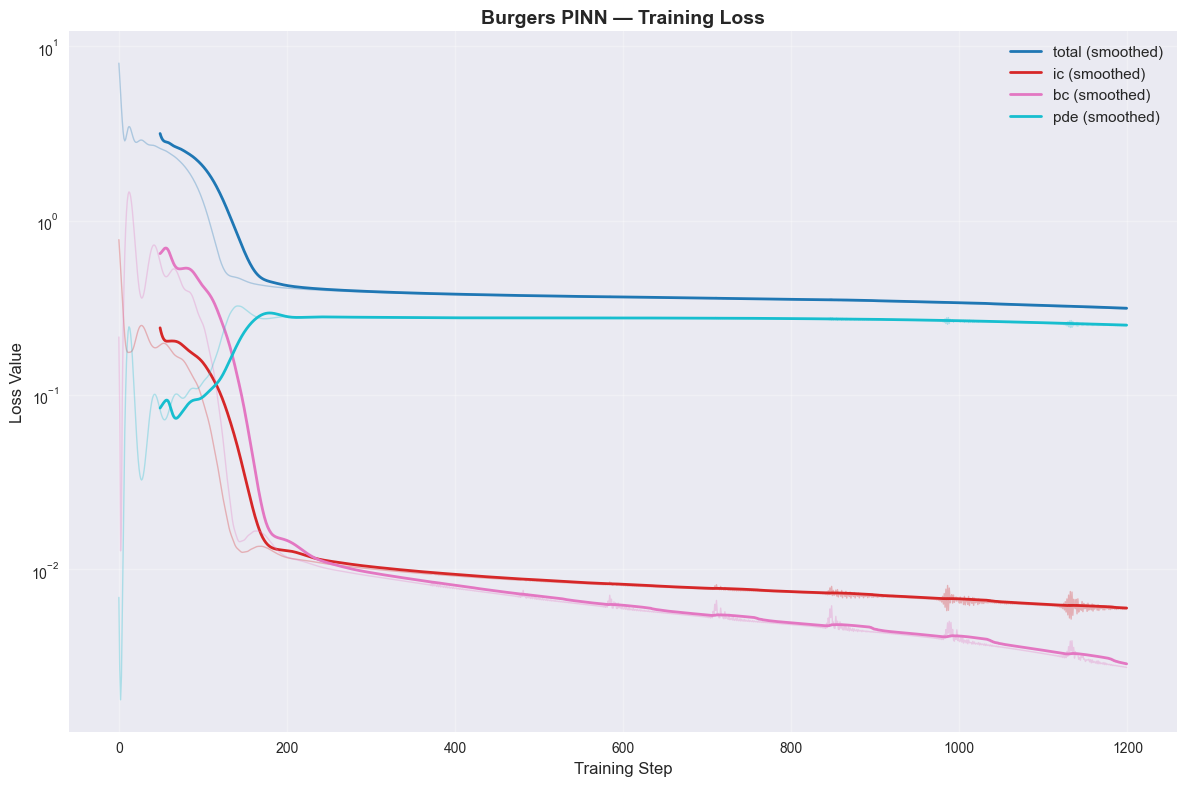

In [4]:
fig = viz.plot_loss_curves(history, title="Burgers PINN — Training Loss", log_scale=True)
plt.show()

<a id="field"></a>

## 4 · 2-D Solution Fields

`plot_2d_field` renders any scalar field over a 2-D grid. Here we show the space–time solution u(t, x).

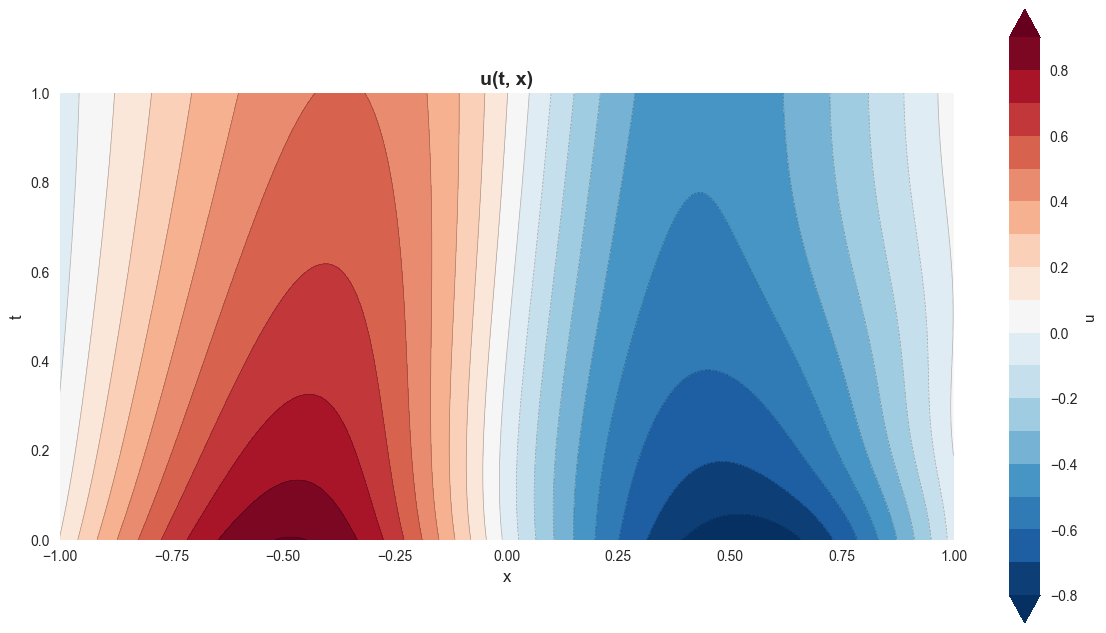

In [5]:
nt, nx = 100, 200
t_grid = np.linspace(cfg.tmin, cfg.tmax, nt, dtype=np.float32)
x_grid = np.linspace(cfg.xmin, cfg.xmax, nx, dtype=np.float32)
TT, XX = np.meshgrid(t_grid, x_grid, indexing="ij")
U = pinn.predict(TT, XX)

fig = viz.plot_2d_field(XX, TT, U, title="u(t, x)", xlabel="x", ylabel="t",
                        colorbar_label="u")
plt.show()

<a id="vector"></a>

## 5 · Vector Fields

For fluid problems, `plot_vector_field_2d` draws velocity arrows. We use the analytic Taylor–Green vortex so the pattern is crisp.

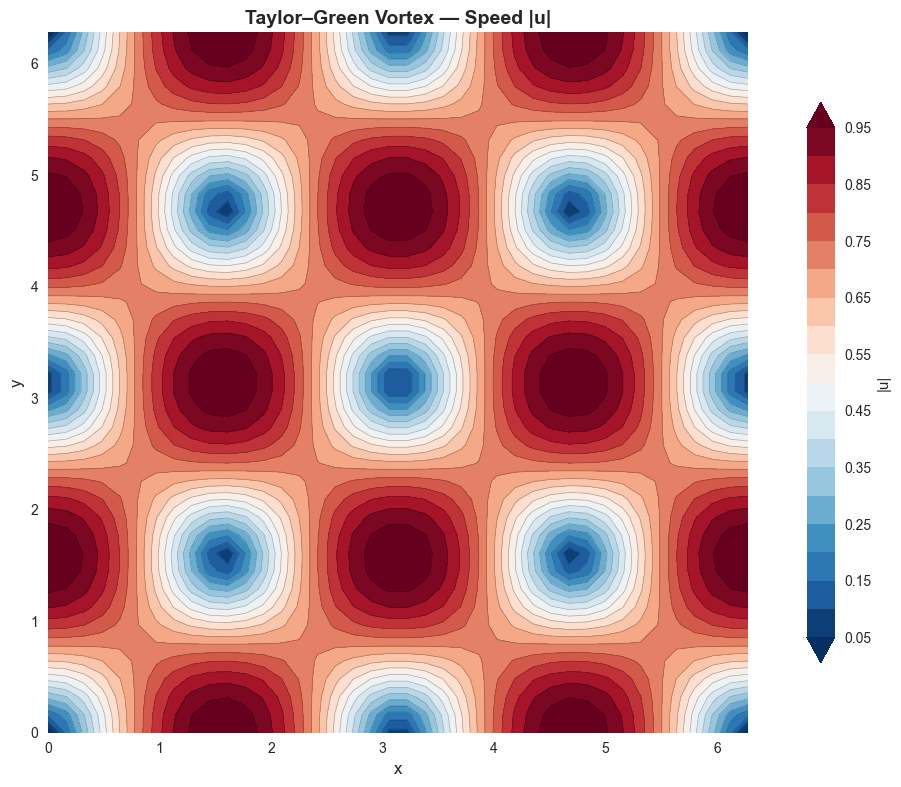

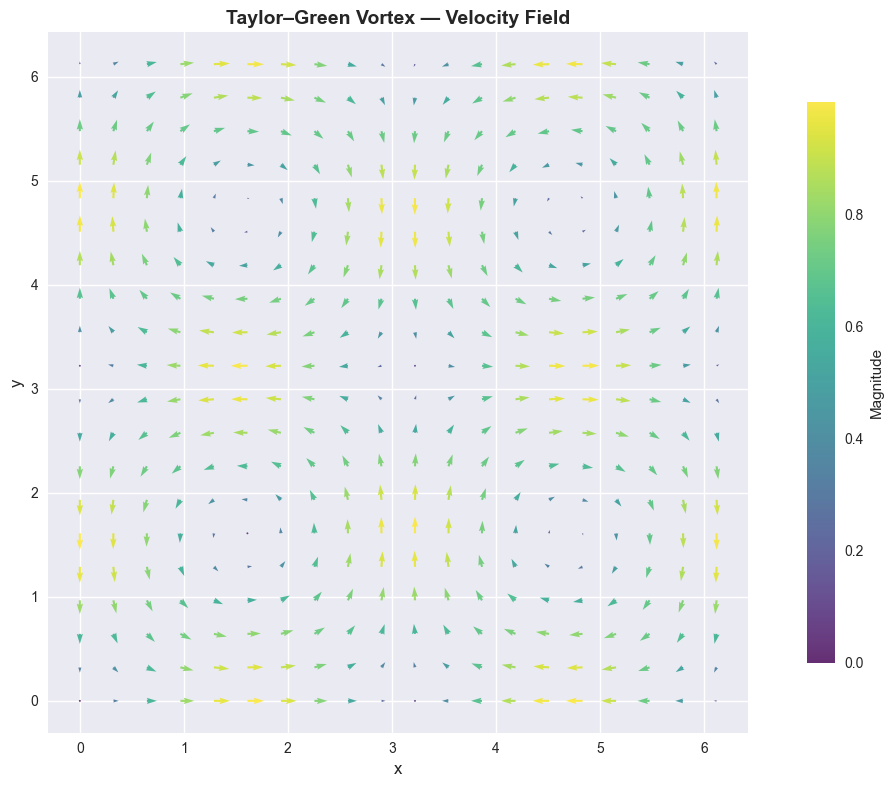

In [6]:
gx = np.linspace(0, 2*np.pi, 40)
X, Y = np.meshgrid(gx, gx)
t, nu = 0.0, 0.01
Uf =  np.sin(X) * np.cos(Y) * np.exp(-2*nu*t)
Vf = -np.cos(X) * np.sin(Y) * np.exp(-2*nu*t)

fig = viz.plot_2d_field(X, Y, np.sqrt(Uf**2 + Vf**2),
                        title="Taylor–Green Vortex — Speed |u|", colorbar_label="|u|")
plt.show()
fig = viz.plot_vector_field_2d(X, Y, Uf, Vf, title="Taylor–Green Vortex — Velocity Field", skip=2)
plt.show()

<a id="error"></a>

## 6 · Error Analysis

`plot_error_analysis` compares a prediction against a reference and summarises the error distribution. We compare the PINN's initial slice to the exact initial condition.

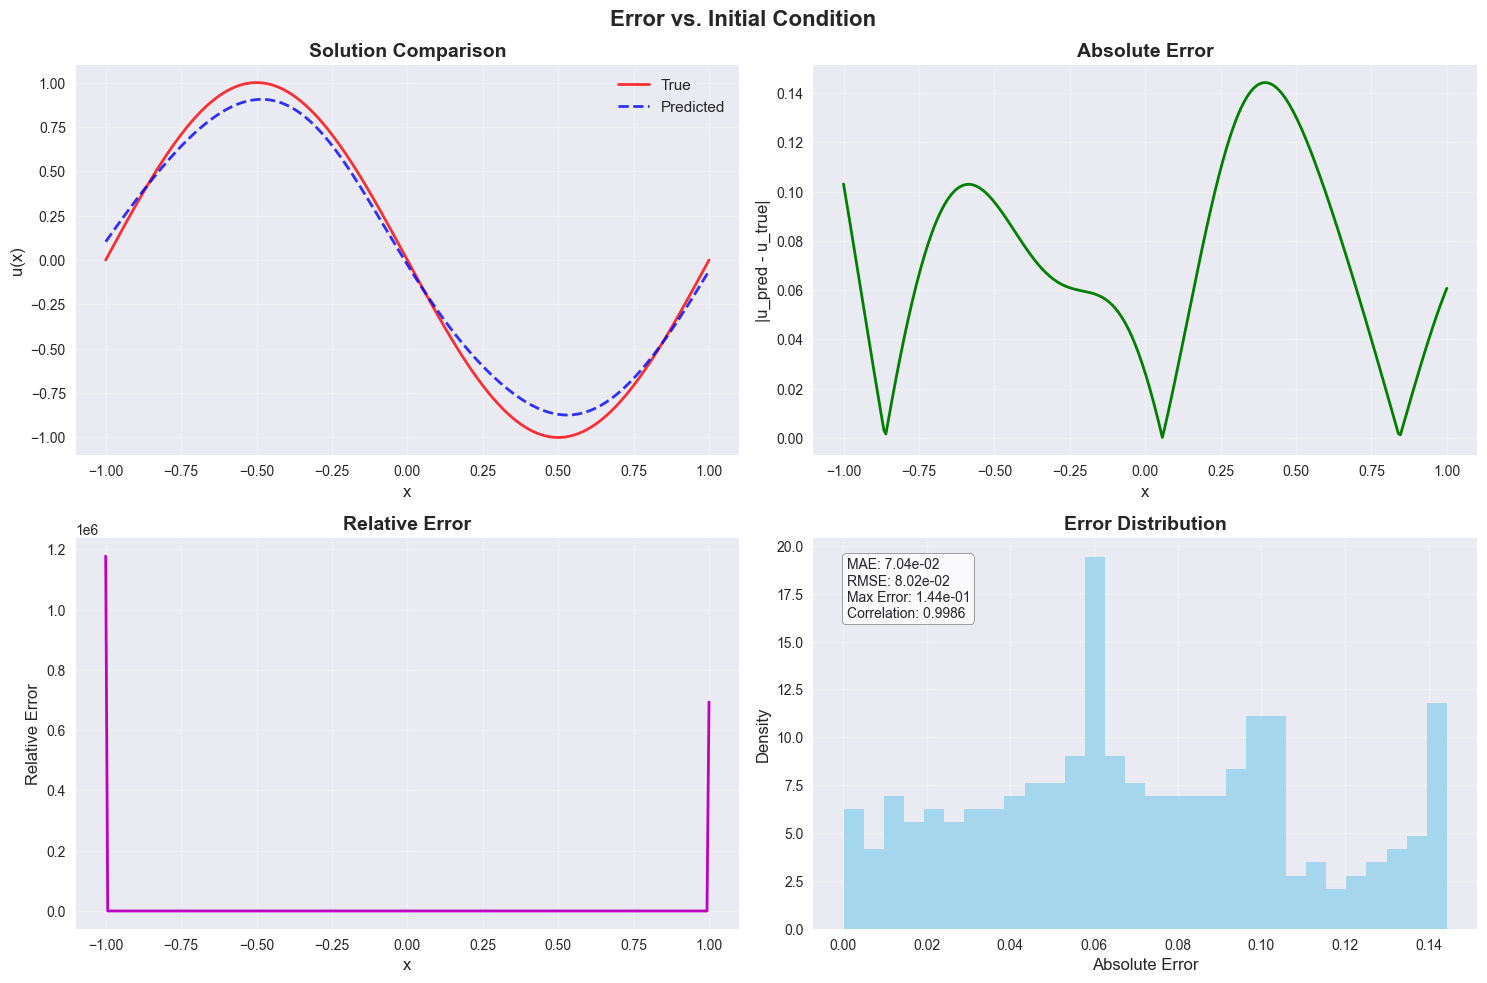

In [7]:
x = np.linspace(cfg.xmin, cfg.xmax, 300, dtype=np.float32)
u_pred = pinn.predict(np.zeros_like(x), x)
u_true = -np.sin(np.pi * x)
fig = viz.plot_error_analysis(x, u_pred, u_true, title="Error vs. Initial Condition")
plt.show()

<a id="takeaways"></a>

## 7 · Takeaways

- `pinnlab.visualization.PINNVisualizer` gives you consistent, styled figures for the most common PINN
  diagnostics — loss curves, 2-D fields, vector fields, and error analysis.
- Each method returns a Matplotlib `Figure`, so you can further customise or save it
  (`save_path=...`).
- Pair these with the metrics in [`02_sampling_and_metrics`](02_sampling_and_metrics.ipynb) for a
  complete validation story.

<div style="background:#0d1117;border-radius:12px;padding:22px 26px;color:#c9d1d9;
            font-family:'Segoe UI',sans-serif;font-size:13px;line-height:1.6;">
  <b style="color:#fff;font-size:15px;">Thanks for reading! 🙌</b><br>
  This notebook is part of the <code>pinnlab</code> example gallery. Explore the companion notebooks in
  <code>notebooks/basic</code>, <code>notebooks/advanced</code>, and <code>notebooks/benchmarks</code>
  for more physics-informed deep-learning recipes.
</div>